## Changes in the Perceptron Algo

In the perceptron trick till now, only the incorrect points had a say in correcting the weights or the coefficient. Now we will listen to all the points, whether correct or not, based on factor like distance.

Earlier the incorrect point used to pull the line closer to itself. Now the correct point will repel or move the line farther away from itself. And the magnitude of this movement will be direcrtly preportional to the distance of the line to the point in the case of wrongly classfied point and indirectly in the case of incorrectly classified point.

Now this magnitude of shift is the new thing we are going to introduce to the previous perceptron algorithm and Sigmoid function maybe the right choice for the overall problem.

## Lets Code and Comapare

In [1]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative = 1, n_redundant= 0, 
                           n_classes = 2, n_clusters_per_class = 1, random_state = 41, hypercube = False, class_sep = 30)

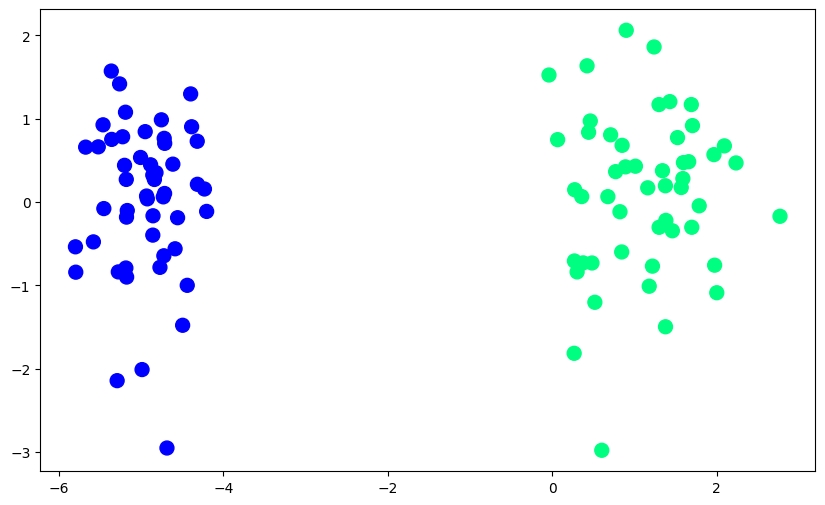

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'winter', s = 100)

### The usual Perceptron thing

In [4]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis = 1) # inserting column for the C in Ax + By + C = 0
    weights = np.ones(X.shape[1]) # starting out with 1,1,1
    lr = 0.1 # this is the learning rate to control the drastic change in each epoch

    for i in range(1000): # working on this for 1000 times
        j = np.random.randint(0, 100) # picking up a random point to work on
        y_hat = step(np.dot(X[j],weights)) # finding the y_hat for the point, where does the point lie relative to the line, we need to further define this step function
        weights = weights + lr * (y[j] - y_hat) * X[j] # chnaging the coefficients/weights based on the position of the point wrt to the line

    return weights[0], weights[1:] # returning the intercept and the coeficients

In [5]:
def step(z):
    return 1 if z>=0 else 0

In [6]:
intercept_, coef_ = perceptron(X, y)

In [7]:
print(coef_)
print(intercept_)

[1.08682872 0.52024363]
1.2000000000000002


In [8]:
m = -( coef_[0]/coef_[1]) # this is the formula for the slope for the line of type Ax + By + C = 0
b = -(intercept_/coef_[1])

In [9]:
# lets try to plot this line and see how good this is
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

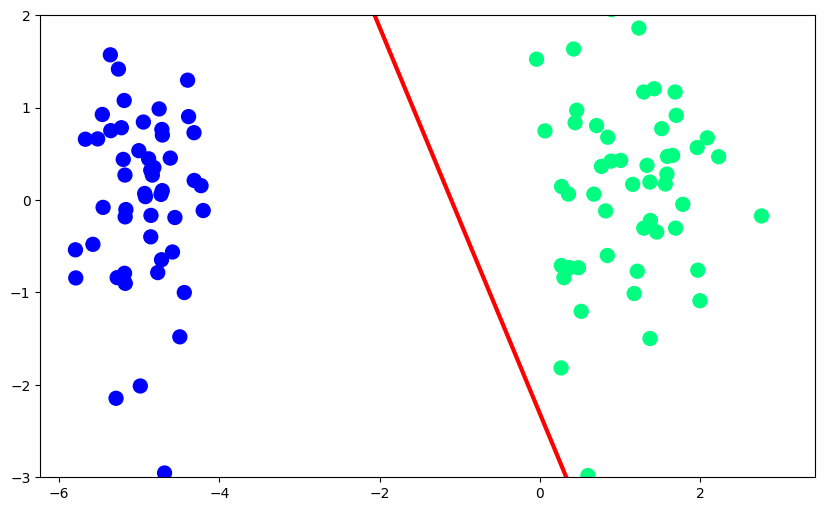

In [10]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3,2)

In [11]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X, y)


LogisticRegression()

In [12]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [13]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input1 + b

(-3.0, 2.0)

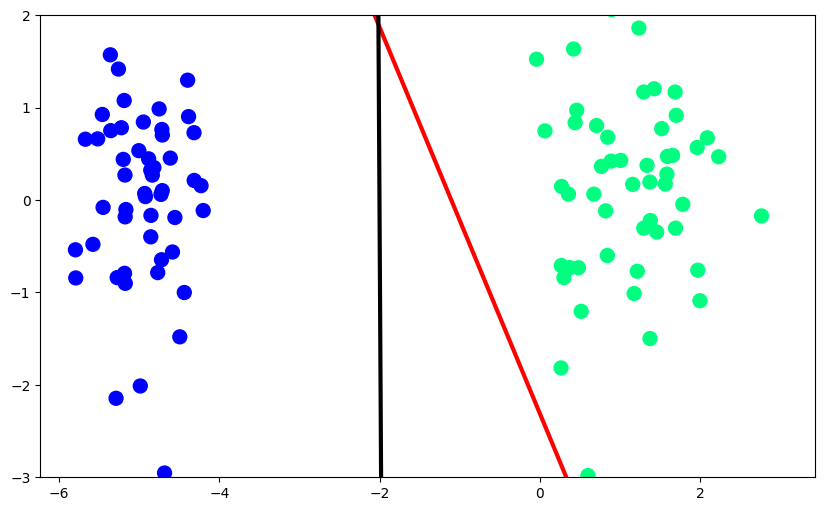

In [14]:
# lets plot them together for a comaprison
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.plot(x_input1, y_input1, color = 'black', linewidth = 3)
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3,2)

### Now lets see how the sigmoid function do the things differently

In [15]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(10000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights)) # this is what has changed, from step function to a sigmoid one
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [16]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [17]:
intercept_,coef_ = perceptron(X,y)

In [18]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [19]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

(-3.0, 2.0)

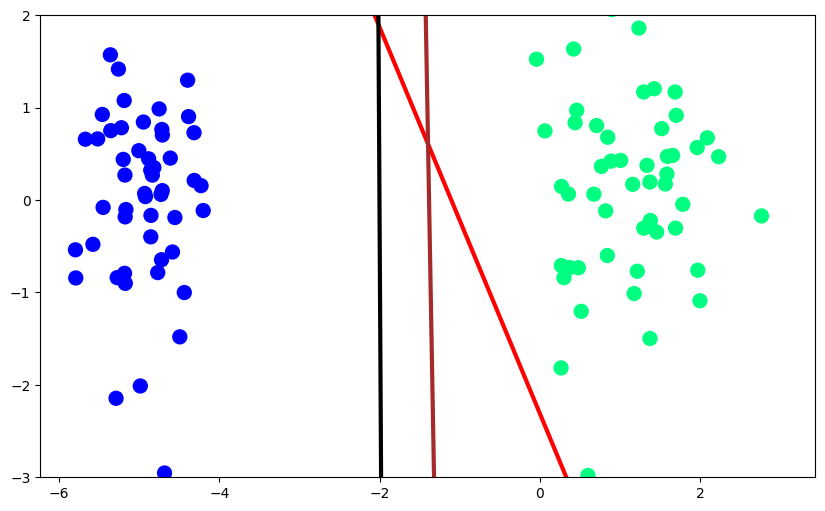

In [20]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

See how the Sigmoid function is a clear improvement compared to the step function in the Perceptron trick, but still its not close the actual Logistic Regression